# API-kald: Beskæftigelsesgrad (Personale-måned)


In [7]:
from pathlib import Path

import pandas as pd
import requests

url = "https://www.krl.dk/sirka/sirkaApi/tableApi"

# JSON (ikke Excel) – vi bruger svaret direkte til at lave figuren
payload = {
  "apiKey": "b6caa39c5a6dc520a83ed1624a7bdfdd1935d9fb2bee1d5e2c14dc08ee4ea57ceacca8e9550f5b25ad07b745a612d4b6b5b07bd781baff0908b5891c0beb65c1",
  "table": "Personale-måned",
  "time": [
    {"y1": "2016", "m1": "02"},
    {"y1": "2017", "m1": "02"},
    {"y1": "2018", "m1": "02"},
    {"y1": "2019", "m1": "02"},
    {"y1": "2020", "m1": "02"},
    {"y1": "2021", "m1": "02"},
    {"y1": "2022", "m1": "02"},
    {"y1": "2023", "m1": "02"},
    {"y1": "2024", "m1": "02"},
    {"y1": "2025", "m1": "02"}
  ],
  "control": [],
  "data": [
    "hoveder",
    "bhhel",
    "bhdel",
    "bhid1",
    "bhid2",
    "bhid3",
    "bhid4",
    "bpt",
    "gnsalle",
    "gnsmnd",
    "gnsdel"
  ],
  "selection": [
    {
      "name": "Udvalgte population",
      "filters": {
        "trb": ["1", "2"],
        "afl": ["0", "1"],
        "omr": ["1", "8"]
      }
    }
  ],
  "options": {
    "totals": True,
    "actions": [],
    "tableName": "Beskæftigelsesgrad",
    "subLimit": 5,
    "modelName": "SIRKA",
    "timeIncreasing": True,
    "tagValues": [
      {"name": "bi1", "dsql": 31},
      {"name": "bi2", "dsql": 27},
      {"name": "bi3", "dsql": 19},
      {"name": "bi1_1", "dsql": 32},
      {"name": "bi2_1", "dsql": 28},
      {"name": "bi3_1", "dsql": 20}
    ]
  },
  "dimension": {
    "viewportHeight": 812,
    "viewportWidth": 1440,
    "xsMaxWidth": 768,
    "smMaxWidth": 992,
    "mdMaxWidth": 1200,
    "CONSTANTS": {"XS": 0, "SM": 1, "MD": 2, "LG": 3, "MAIL": 4}
  }
}

response = requests.post(url, json=payload, timeout=60)
print("HTTP:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
response.raise_for_status()

raw = response.json()
if isinstance(raw, dict) and isinstance(raw.get("data"), list):
    raw = raw["data"]

df_raw = pd.DataFrame(raw)
print("Rows:", len(df_raw))
print("Columns:", list(df_raw.columns)[:20])

# Find en tidskolonne (typisk '_YM' = YYYYMM)
time_col = None
for candidate in ["_YM", "YM", "ym", "time", "_TIME"]:
    if candidate in df_raw.columns:
        time_col = candidate
        break
if time_col is None:
    raise RuntimeError(f"Kunne ikke finde tidskolonne i svaret. Kolonner: {list(df_raw.columns)}")

years = df_raw[time_col].astype(str).str[:4].astype(int)

# Andel deltid i pct: bhdel / hoveder (fallback: bhdel / (bhdel + bhhel))
if "bhdel" not in df_raw.columns:
    raise RuntimeError("Svaret mangler 'bhdel' (deltid).")

if "hoveder" in df_raw.columns:
    denom = df_raw["hoveder"].replace({0: pd.NA})
else:
    if "bhhel" not in df_raw.columns:
        raise RuntimeError("Svaret mangler både 'hoveder' og 'bhhel' til beregning af andel.")
    denom = (df_raw["bhdel"] + df_raw["bhhel"]).replace({0: pd.NA})

share_pct = (df_raw["bhdel"] / denom) * 100

df_share = (
    pd.DataFrame({"År": years, "Andel (pct.)": share_pct})
    .dropna()
    .groupby("År", as_index=False)
    .mean()
    .sort_values("År")
)

df_share

HTTP: 200
Content-Type: application/json; charset=utf-8
Rows: 10
Columns: ['_YM', '_BM', 'hoveder', 'bhhel', 'bhdel', 'bhid1', 'bhid2', 'bhid3', 'bhid4', 'bpt', 'gnsalle', 'gnsmnd', 'gnsdel']


,År,Andel (pct.)
0,2016,36.541288
1,2017,36.234968
2,2018,35.737911
3,2019,35.520324
4,2020,35.711860
5,2021,35.177661
6,2022,34.997559
7,2023,34.163098
8,2024,33.490091
9,2025,33.064370


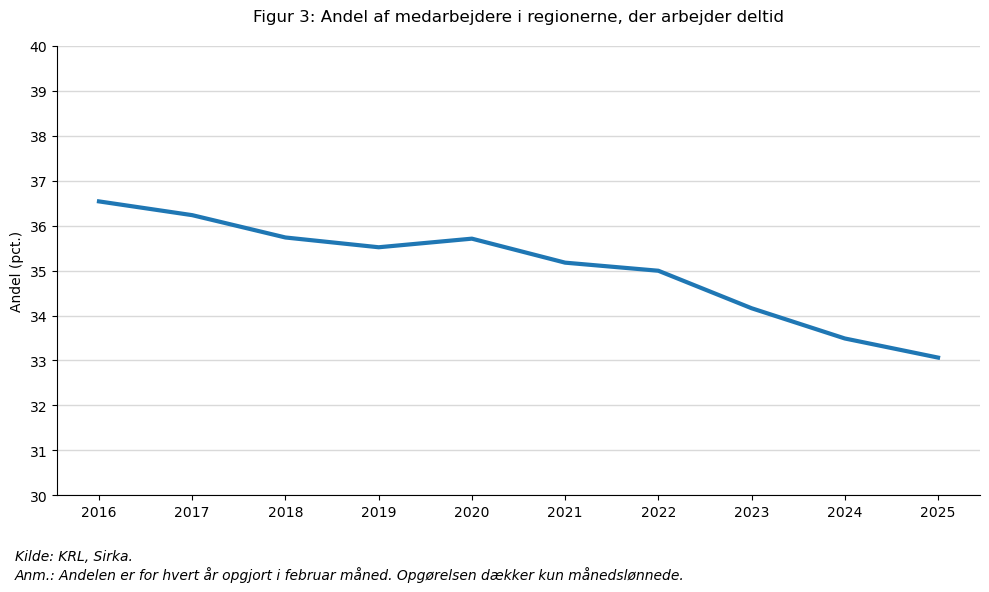

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Figur 3: Andel af medarbejdere i regionerne, der arbejder deltid
fig, ax = plt.subplots(figsize=(10, 6))

x = df_share["År"].to_numpy()
y = df_share["Andel (pct.)"].to_numpy()

ax.plot(x, y, linewidth=3)

ax.set_title("Figur 3: Andel af medarbejdere i regionerne, der arbejder deltid", pad=18)
ax.set_ylabel("Andel (pct.)")
ax.set_xticks(x)

# Match look: kun vandrette hjælpelinjer
ax.grid(axis="y", color="#d9d9d9", linewidth=1)
ax.grid(axis="x", visible=False)

# Sæt akse-interval som i eksemplet (30-40)
ax.set_ylim(30, 40)
ax.set_yticks(np.arange(30, 41, 1))

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout(rect=(0, 0.10, 1, 1))
fig.text(
    0.02,
    0.02,
    "Kilde: KRL, Sirka.\nAnm.: Andelen er for hvert år opgjort i februar måned. Opgørelsen dækker kun månedslønnede.",
    ha="left",
    va="bottom",
    fontsize=10,
    fontstyle="italic",
)

plt.show()